In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the Data

In [2]:
columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin', 'car name']
data = pd.read_csv('auto-mpg.data', header=None, sep="\\s+", names=columns)

data.info(), data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


(None,
     mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
 0  18.0          8         307.0      130.0  3504.0          12.0          70   
 1  15.0          8         350.0      165.0  3693.0          11.5          70   
 2  18.0          8         318.0      150.0  3436.0          11.0          70   
 3  16.0          8         304.0      150.0  3433.0          12.0          70   
 4  17.0          8         302.0      140.0  3449.0          10.5          70   
 
    origin                   car name  
 0       1  chevrolet chevelle malibu  
 1       1          buick skylark 320  
 2       1         plymouth satellite  
 3       1              amc rebel sst  
 4       1                ford torino  )



#### Note that the horsepower column is of data-type object instead of float64, this means that there might be strings in the column

In [3]:
data['horsepower'] = data['horsepower'].replace('?', np.nan).astype('float')
data['horsepower'].info(), data['horsepower'].isna().sum()

<class 'pandas.core.series.Series'>
RangeIndex: 398 entries, 0 to 397
Series name: horsepower
Non-Null Count  Dtype  
--------------  -----  
392 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


(None, np.int64(6))

In [4]:
# The inplace parameter is necessary to apply the changes to the current dataset, else a new df is returned
data.dropna(inplace=True)

# An alternative will be to use:

# data = data.dropna()


In [5]:
data.isna().sum()

# Dataset is cleaned

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 30.6+ KB


In [6]:
X_df = data.drop(['mpg', 'car name'], axis=1)
y_df = data['mpg']


## 2. Split the Data into training and test sets

In [7]:
from sklearn.model_selection import train_test_split
X = X_df.values
y = y_df.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((313, 7), (79, 7), (313,), (79,))

## 3. Initialize the model

In [9]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)

print("Model Trained Successfully \n")

print("The model's weights are: \n")

for weight, column in  zip(linreg.coef_, X_df.columns):
    print(f'{column}: {weight:.3f} \n')

print(f"Model's bias is {linreg.intercept_:^10}")

Model Trained Successfully 

The model's weights are: 

cylinders: -0.346 

displacement: 0.015 

horsepower: -0.021 

weight: -0.006 

acceleration: 0.038 

model year: 0.768 

origin: 1.613 

Model's bias is -18.49936112872476


In [10]:
linreg.coef_, linreg.intercept_.item()

(array([-0.34578883,  0.01510871, -0.02130175, -0.00614163,  0.03795001,
         0.76774258,  1.61345707]),
 -18.49936112872476)

##  4. Model Prediction

In [11]:
y_pred = linreg.predict(X_test)

y_pred[:1], y_test[:1]

(array([25.84156153]), array([26.]))

## 5. Model Evaluation

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f} \n")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}\n ")

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2): {r2:.2f}\n")

Mean Squared Error (MSE): 10.71 

Root Mean Squared Error (RMSE): 3.27
 
R-squared (R2): 0.79



In [13]:
min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())

(np.float64(7.136725882457615), np.float64(44.0))

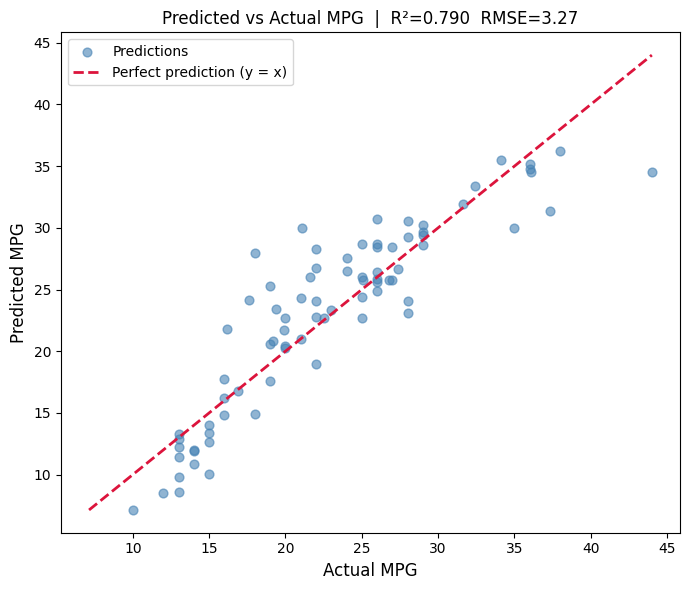

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred, alpha=0.6, color="steelblue", s=40, label="Predictions")

# Diagonal reference line — perfect prediction
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color="crimson", lw=2, linestyle="--", label="Perfect prediction (y = x)")

ax.set_xlabel("Actual MPG",    fontsize=12)
ax.set_ylabel("Predicted MPG", fontsize=12)
ax.set_title(f"Predicted vs Actual MPG  |  R²={r2:.3f}  RMSE={rmse:.2f}",
             fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()